In [1]:
import numpy as np
from matplotlib import pyplot as plt
import cv2
from pathlib import Path

# Make plots a reasonable size in the notebook.
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['image.interpolation'] = 'nearest'


## Lab 3: Image clustering and superpixels

In this lab we are going to explore image clustering and superpixels segmentation. You will be required to complete the following tasks:

1. Implement k-means clustering to assign each pixel of an image to one of K distinct clusters, using colour similarity to determine assignment.
2. Modify your k-means clustering to find superpixels by assigning each pixel of the image to one of K distinct clusters, using both colour and location similarity to determine assignment.
3. Use superpixels to propose regions of interest in the image (we will learn about neural networks that use this information in week 11). 
4. Write a brief report (max 600 words) discussing explaining your implementation and results. Explain your reasoning by referencing the intermediate result figures you generated. 

You may use numpy and matplotlib and opencv for image loading.

### Academic integrity

Every lab submission will be screened for any collusion and/or plagiarism. Breaches of academic integrity will be investigated thoroughly and may result in a zero for the assessment along with interviews with the plagiarism officers at Monash University.

### Late submissions

The default late submission university penalty will apply.

### Lab Instructions and the Use of Generative AI

You may not use any built-in opencv functions for this lab, other than those used for loading/ saving an image, extracting and matching keypoints, and
computing homographies.
* You may use NumPy for array handling, and vectorizing your code (reducing
the number of for-loops) is encouraged.
* You should use Matplotlib to display images and any intermediate results.
* You may use generative AI.

### Grading
Each lab is worth 8%, and there are a number of sections and tasks with their own weighting. A task is only considered complete if you can demonstrate a working program and show an understanding of the underlying concepts. Note that later tasks should reuse code from earlier tasks.

Masks will be provided based on the correctness of the code, the quality of your results, comments indicating you understand your work, and a discussion of tasks provided at the end of the notebook. 

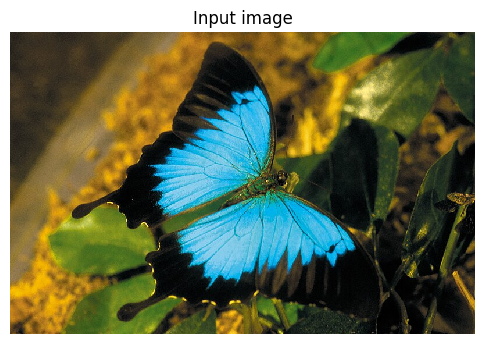

In [2]:
# Load and display image for testing.
# OpenCV loads in BGR order, so convert to RGB for easier interpretation and plotting.
im_bgr = cv2.imread('CSIRO_ScienceImage_3831_Ulysses_Butterfly.jpg')
assert im_bgr is not None, 'Image file was not found. Run the notebook from the lab3 folder.'
im = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

plt.figure(figsize=(6, 4))
plt.imshow(im)
plt.title('Input image')
plt.axis('off')
plt.show()


### Task 1: Implement K-means from first principles: colour similarity

Fill in the function below to implement the following steps. Your function should accept an image, a variable storing the number of iterations to repeat k-means for, the number of clusters K.
1. Flatten the image into an Nx3 vector of pixels (num pixels x r,g,b colour of pixel)
2. Select K random colour centroids
3. Repeat for n iterations:
   1. Assign each pixel in the vector to a cluster and store the index corresponding to this in a numpy array
   2. Update the centroid locations using the new cluster assignments
   3. Save the total loss at each iteration
4. Convert the cluster index array back into a 2D array the same size as the image, where each pixel contains the corresponding cluster index
5. Create a new quantised image, where each pixel is coloured according to the centroid corresponding to a given cluster index.
6. Return the loss, cluster index image and quantised image
7. Test your function on the sample image provided, and select an appropriate number of iterations 
8. Display the results for a number of choices of K. Use the returned losses to select an appropriate value for K 

In [3]:
def kmeans(im, iters=10, K=3, plot=False):
    """Colour-only k-means implemented from first principles.

    Parameters
    ----------
    im : np.ndarray, shape (H, W, 3), float in [0, 1]
        RGB image.
    iters : int
        Number of centroid assignment/update iterations.
    K : int
        Number of clusters.
    plot : bool
        If True, show the quantised result after each iteration.

    Returns
    -------
    losses : list[float]
        Sum of squared colour distances after each iteration.
    cluster_idx_image : np.ndarray, shape (H, W)
        Integer cluster label for each pixel.
    quantised_image : np.ndarray, shape (H, W, 3)
        Image where each pixel is replaced by its cluster centroid colour.
    """
    seed = 42
    rng = np.random.default_rng(seed)

    H, W, C = im.shape
    assert C == 3, 'Expected an RGB image with three colour channels.'

    # Convert image into an Nx3 vector of pixels.
    pixels = im.reshape(-1, 3).astype(np.float32)
    N = pixels.shape[0]

    # Select K random colour centroids from actual image pixels.
    initial_idx = rng.choice(N, size=K, replace=False)
    centroids = pixels[initial_idx].copy()

    losses = []
    cluster_indices = np.zeros(N, dtype=np.int32)

    for j in range(iters):
        # Assign pixels to clusters using squared Euclidean colour distance.
        # dists has shape (N, K).
        dists = np.sum((pixels[:, None, :] - centroids[None, :, :]) ** 2, axis=2)
        cluster_indices = np.argmin(dists, axis=1).astype(np.int32)

        # Store the current loss before updating centroids.
        loss = float(np.sum(dists[np.arange(N), cluster_indices]))
        losses.append(loss)

        # Update centroid locations using new cluster assignments.
        new_centroids = centroids.copy()
        for k in range(K):
            members = pixels[cluster_indices == k]
            if len(members) > 0:
                new_centroids[k] = members.mean(axis=0)
            else:
                # If a cluster becomes empty, reinitialise it to a random pixel.
                new_centroids[k] = pixels[rng.integers(0, N)]
        centroids = new_centroids

        # Convert cluster indices to an image.
        cluster_idx_image = cluster_indices.reshape(H, W)

        # Create a quantised image using the clustering.
        quantised_image = centroids[cluster_indices].reshape(H, W, 3)

        if plot:
            plt.figure(figsize=(5, 4))
            plt.imshow(np.clip(quantised_image, 0, 1))
            plt.title(f'Colour k-means: K={K}, iteration={j + 1}, loss={loss:.1f}')
            plt.axis('off')
            plt.show()

    return losses, cluster_idx_image, np.clip(quantised_image, 0, 1)


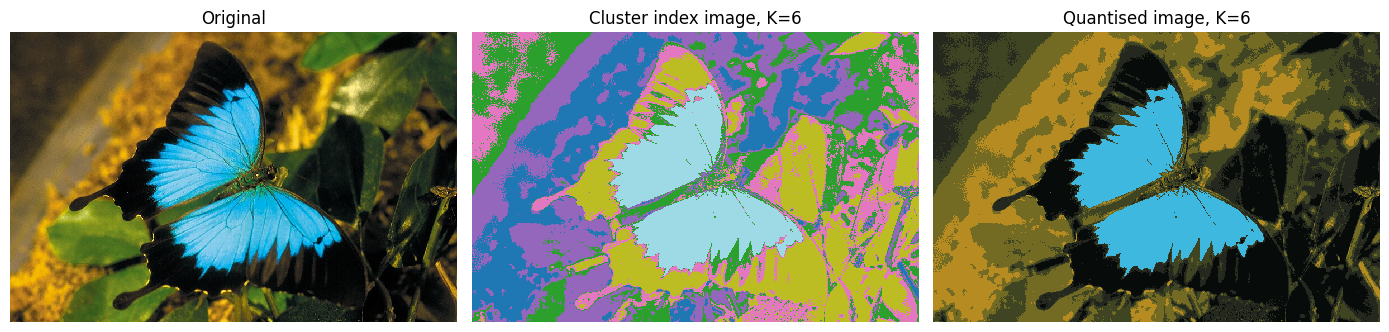

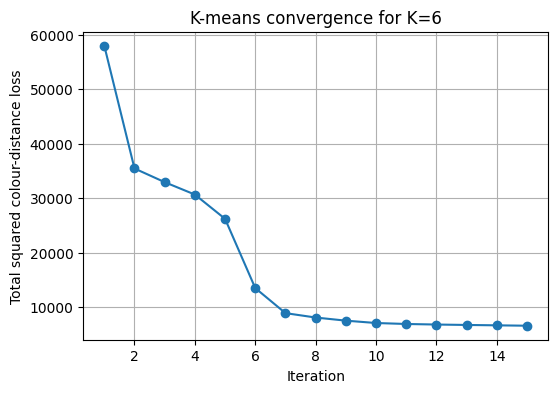

In [4]:
# Test the colour-only k-means function using the image provided.
losses_6, labels_6, quantised_6 = kmeans(im, iters=15, K=6)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(im)
ax[0].set_title('Original')
ax[1].imshow(labels_6, cmap='tab20')
ax[1].set_title('Cluster index image, K=6')
ax[2].imshow(quantised_6)
ax[2].set_title('Quantised image, K=6')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(losses_6) + 1), losses_6, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Total squared colour-distance loss')
plt.title('K-means convergence for K=6')
plt.grid(True)
plt.show()


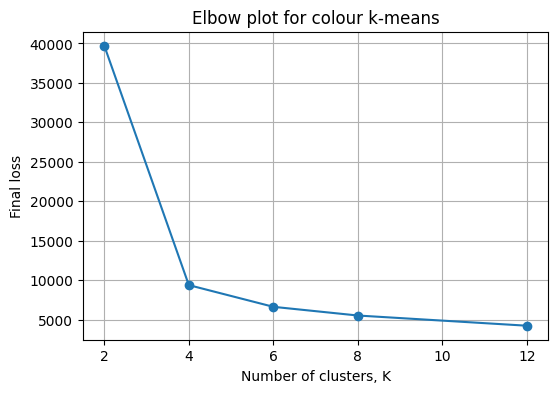

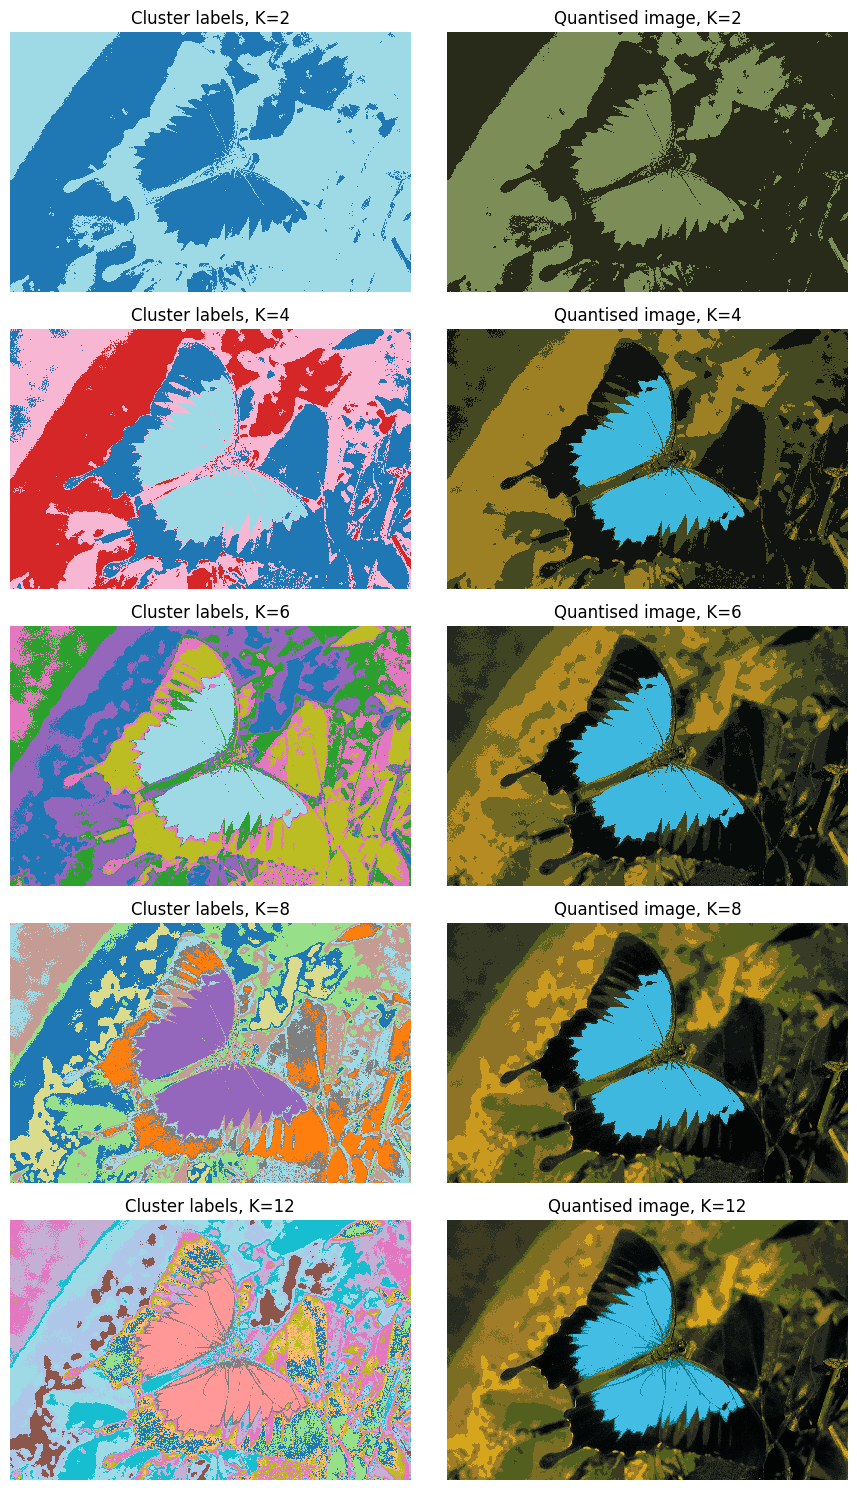

Final losses:
K= 2: 39715.50
K= 4: 9368.06
K= 6: 6615.73
K= 8: 5512.48
K=12: 4219.71

Chosen K for colour quantisation: K=6. It keeps the main butterfly/background colours while avoiding unnecessary small clusters.


In [5]:
# Select an appropriate value for K and use visualisations to show how this was done.
# The same number of iterations is used for a fair comparison.
K_values = [2, 4, 6, 8, 12]
results = {}

for K in K_values:
    losses, labels, quantised = kmeans(im, iters=15, K=K)
    results[K] = {'losses': losses, 'labels': labels, 'quantised': quantised}

plt.figure(figsize=(6, 4))
plt.plot(K_values, [results[K]['losses'][-1] for K in K_values], marker='o')
plt.xlabel('Number of clusters, K')
plt.ylabel('Final loss')
plt.title('Elbow plot for colour k-means')
plt.grid(True)
plt.show()

fig, axes = plt.subplots(len(K_values), 2, figsize=(9, 3 * len(K_values)))
for row, K in enumerate(K_values):
    axes[row, 0].imshow(results[K]['labels'], cmap='tab20')
    axes[row, 0].set_title(f'Cluster labels, K={K}')
    axes[row, 1].imshow(results[K]['quantised'])
    axes[row, 1].set_title(f'Quantised image, K={K}')
    axes[row, 0].axis('off')
    axes[row, 1].axis('off')
plt.tight_layout()
plt.show()

print('Final losses:')
for K in K_values:
    print(f'K={K:2d}: {results[K]["losses"][-1]:.2f}')
print('\nChosen K for colour quantisation: K=6. It keeps the main butterfly/background colours while avoiding unnecessary small clusters.')


### Task 2: Modify K-means to cluster based on colour similarity and pixel location and extract superpixels

1. Modify the k_means function above to segment based on colour and pixel location, so that you extract superpixels.

2. Test your implementation by clustering the image into 50 superpixels.

3. Select an appropriate pixel coordinate scaling factor so that you trade-off incorporating colour information into the clustering, while ensuring superpixel continuity (all pixels in a superpixel must remain connected).

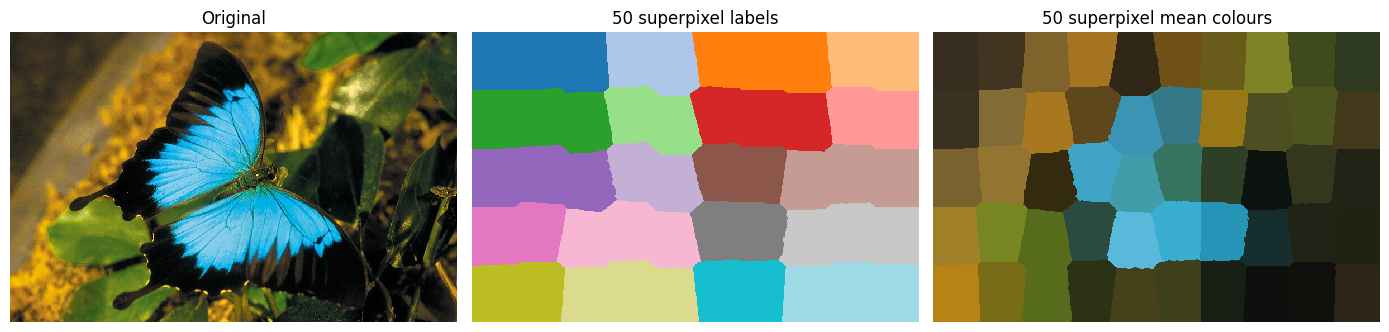

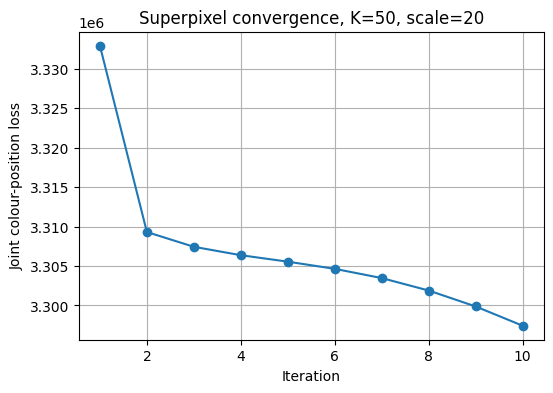

In [ ]:
# Use a modified k-means / SLIC-style function to cluster based on colour and location.
def superpixel_kmeans(im, iters=10, K=50, scale=20, plot=False):
    """Cluster an image into superpixels using colour and pixel location.

    This is a first-principles, SLIC-style modification of k-means. Each cluster
    centre stores [y, x, r, g, b]. During assignment, a pixel is compared only to
    nearby centres, which encourages spatially continuous superpixels.

    Parameters
    ----------
    im : np.ndarray, shape (H, W, 3), float in [0, 1]
        RGB image.
    iters : int
        Number of centroid assignment / update iterations.
    K : int
        Desired number of superpixels.
    scale : float
        Spatial scaling / compactness factor. Larger values give more compact,
        spatially regular superpixels. Smaller values behave more like colour-only
        clustering.
    plot : bool
        If True, show the superpixel mean-colour image after each iteration.

    Returns
    -------
    losses : list[float]
        Total assignment distance after each iteration.
    cluster_idx_image : np.ndarray, shape (H, W)
        Integer superpixel label for each pixel.
    quantised_image : np.ndarray, shape (H, W, 3)
        Image where each pixel is replaced by its superpixel mean colour.
    """
    H, W, C = im.shape
    assert C == 3, 'Expected an RGB image with three colour channels.'

    # Grid spacing used for initialisation and local search.
    N = H * W
    S = np.sqrt(N / float(K))

    # Place initial centres on a coarse grid.
    grid_rows = max(1, int(np.sqrt(K * H / W)))
    grid_cols = int(np.ceil(K / grid_rows))
    ys = np.linspace(S / 2, H - S / 2, grid_rows)
    xs = np.linspace(S / 2, W - S / 2, grid_cols)

    centres = []
    for y in ys:
        for x in xs:
            yi = int(np.clip(round(y), 0, H - 1))
            xi = int(np.clip(round(x), 0, W - 1))
            centres.append([y, x, im[yi, xi, 0], im[yi, xi, 1], im[yi, xi, 2]])
    centres = np.array(centres[:K], dtype=np.float32)
    K = len(centres)

    yy, xx = np.mgrid[0:H, 0:W]
    labels = -np.ones((H, W), dtype=np.int32)
    distances = np.full((H, W), np.inf, dtype=np.float32)
    losses = []

    for j in range(iters):
        distances.fill(np.inf)

        # Assign pixels to the nearest nearby centre using a colour + location metric.
        for k, centre in enumerate(centres):
            cy, cx, cr, cg, cb = centre
            y0 = max(int(cy - S), 0)
            y1 = min(int(cy + S) + 1, H)
            x0 = max(int(cx - S), 0)
            x1 = min(int(cx + S) + 1, W)

            region = im[y0:y1, x0:x1]
            colour_dist = np.sqrt(np.sum((region - np.array([cr, cg, cb], dtype=np.float32)) ** 2, axis=2))
            spatial_dist = np.sqrt((yy[y0:y1, x0:x1] - cy) ** 2 + (xx[y0:y1, x0:x1] - cx) ** 2)

            # Larger scale -> greater emphasis on compact, connected superpixels.
            D = colour_dist + (scale / S) * spatial_dist

            update_mask = D < distances[y0:y1, x0:x1]
            distances[y0:y1, x0:x1][update_mask] = D[update_mask]
            labels[y0:y1, x0:x1][update_mask] = k

        # Enforce that each superpixel label remains connected.
        # If a label has multiple disconnected components, keep the largest
        # component and reassign the others to the next-best nearby label.
        for k in range(K):
            mask = labels == k
            if not np.any(mask):
                continue
            n_cc, cc_labels = cv2.connectedComponents(mask.astype(np.uint8), connectivity=8)
            if n_cc <= 1:
                continue

            # Keep the largest connected component for this label.
            counts = np.bincount(cc_labels.flatten())
            counts[0] = 0
            largest_cc = int(np.argmax(counts))
            for cc in range(1, n_cc):
                if cc == largest_cc:
                    continue
                component_mask = cc_labels == cc
                component_coords = np.stack(np.nonzero(component_mask), axis=1)
                component_pixels = im[component_mask]
                cy_cc = component_coords[:, 0].astype(np.float32)
                cx_cc = component_coords[:, 1].astype(np.float32)

                colour_dist = np.sqrt(np.sum((component_pixels[:, None, :] - centres[:, 2:][None, :, :]) ** 2, axis=2))
                spatial_dist = np.sqrt((cy_cc[:, None] - centres[:, 0][None, :]) ** 2 + (cx_cc[:, None] - centres[:, 1][None, :]) ** 2)
                D_all = colour_dist + (scale / S) * spatial_dist
                D_all[:, k] = np.inf
                new_labels = np.argmin(D_all, axis=1)
                labels[component_mask] = new_labels

        loss = float(np.sum(distances[np.isfinite(distances)]))
        losses.append(loss)

        # Update centre positions and mean colours.
        new_centres = centres.copy()
        for k in range(K):
            mask = labels == k
            if np.any(mask):
                ys_k, xs_k = np.where(mask)
                colours = im[mask]
                new_centres[k, 0] = ys_k.mean()
                new_centres[k, 1] = xs_k.mean()
                new_centres[k, 2:] = colours.mean(axis=0)
        centres = new_centres

        quantised_image = centres[:, 2:][labels].reshape(H, W, 3)

        if plot:
            plt.figure(figsize=(5, 4))
            plt.imshow(np.clip(quantised_image, 0, 1))
            plt.title(f'Superpixels: K={K}, scale={scale}, iteration={j + 1}')
            plt.axis('off')
            plt.show()

    cluster_idx_image = labels
    quantised_image = centres[:, 2:][labels].reshape(H, W, 3)
    return losses, cluster_idx_image, np.clip(quantised_image, 0, 1)

# Test the implementation by clustering the image into 50 superpixels.
sp_losses_50, sp_labels_50, sp_quantised_50 = superpixel_kmeans(im, iters=10, K=50, scale=5)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(im)
ax[0].set_title('Original')
ax[1].imshow(sp_labels_50, cmap='tab20')
ax[1].set_title('50 superpixel labels')
ax[2].imshow(sp_quantised_50)
ax[2].set_title('50 superpixel mean colours')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(sp_losses_50) + 1), sp_losses_50, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Joint colour-position loss')
plt.title('Superpixel convergence, K=50, scale=20')
plt.grid(True)
plt.show()


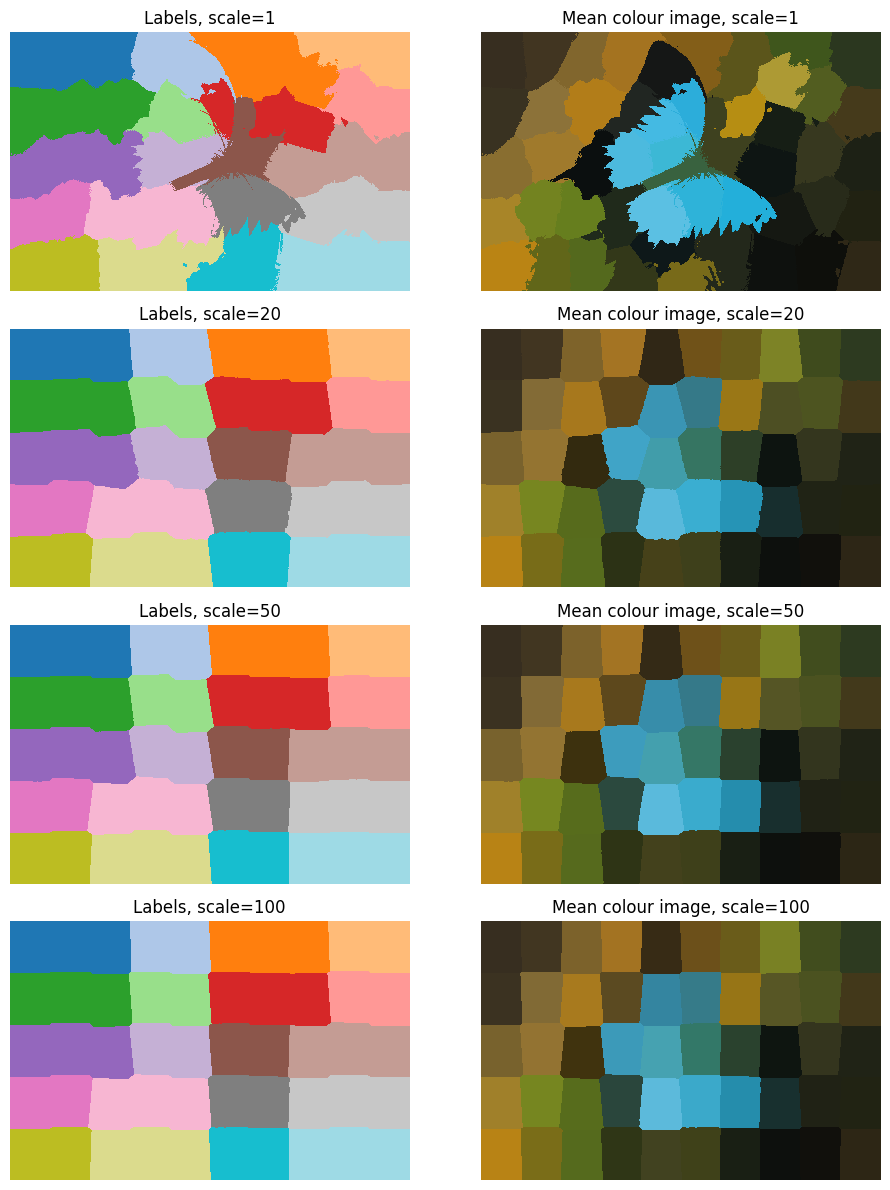

Chosen spatial scaling factor: 20
Reason: scale=1 behaves closer to colour-only clustering and is less spatially regular. scale=50 and 100 force very compact superpixels but smooth away some boundaries. scale=20 gives a better trade-off between respecting colour changes and maintaining connected superpixels.


In [7]:
# Visualise superpixel clustering for different spatial scaling parameters.
scales = [1, 20, 50, 100]
scale_results = {}

for scale in scales:
    losses, labels, quantised = superpixel_kmeans(im, iters=10, K=50, scale=scale)
    scale_results[scale] = {'losses': losses, 'labels': labels, 'quantised': quantised}

fig, axes = plt.subplots(len(scales), 2, figsize=(10, 3 * len(scales)))
for row, scale in enumerate(scales):
    axes[row, 0].imshow(scale_results[scale]['labels'], cmap='tab20')
    axes[row, 0].set_title(f'Labels, scale={scale}')
    axes[row, 1].imshow(scale_results[scale]['quantised'])
    axes[row, 1].set_title(f'Mean colour image, scale={scale}')
    axes[row, 0].axis('off')
    axes[row, 1].axis('off')
plt.tight_layout()
plt.show()

print('Chosen spatial scaling factor: 20')
print('Reason: scale=1 behaves closer to colour-only clustering and is less spatially regular. scale=50 and 100 force very compact superpixels but smooth away some boundaries. scale=20 gives a better trade-off between respecting colour changes and maintaining connected superpixels.')


## Task 3: Region proposal

Segment your image into 10 superpixels. Then find the locations of the top left pixel and bottom right pixel in a superpixel, and use this information and the cv2.rectangle function to draw rectangles (regions) on the original image for each superpixel.


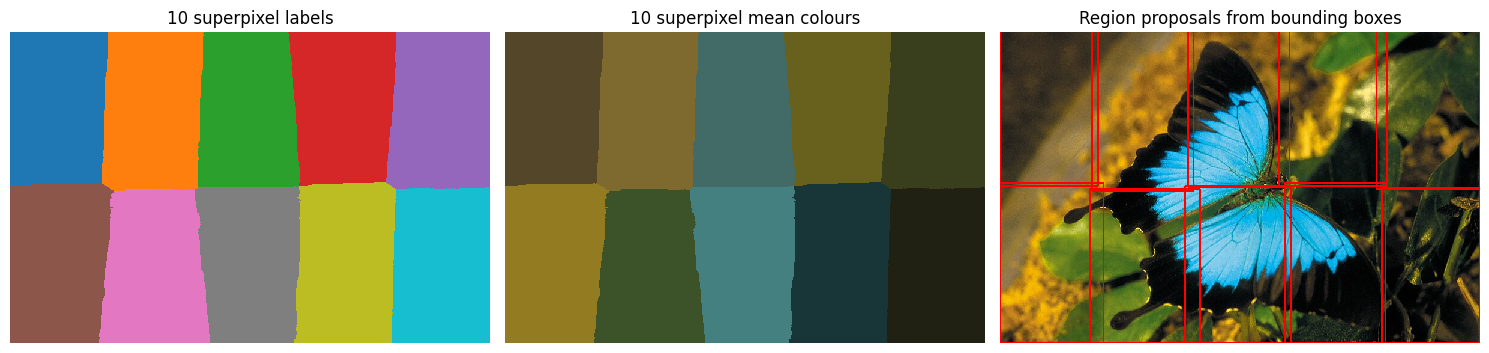

Bounding boxes: label, x_min, y_min, x_max, y_max
(0, 0, 0, 163, 257)
(1, 153, 0, 322, 265)
(2, 313, 0, 482, 259)
(3, 464, 0, 644, 257)
(4, 627, 0, 799, 262)
(5, 0, 253, 172, 518)
(6, 149, 262, 333, 518)
(7, 308, 258, 484, 518)
(8, 474, 252, 642, 518)
(9, 636, 260, 799, 518)


In [8]:
# Visualise proposed regions on the original image.
# Use 10 superpixels, then draw one bounding box around each superpixel label.
_, region_labels, region_quantised = superpixel_kmeans(im, iters=10, K=10, scale=20)
H, W = region_labels.shape

region_image = (im * 255).astype(np.uint8).copy()
boxes = []

for k in range(region_labels.max() + 1):
    ys, xs = np.where(region_labels == k)
    if len(xs) == 0:
        continue
    x_min, x_max = int(xs.min()), int(xs.max())
    y_min, y_max = int(ys.min()), int(ys.max())
    boxes.append((k, x_min, y_min, x_max, y_max))
    cv2.rectangle(region_image, (x_min, y_min), (x_max, y_max), color=(255, 0, 0), thickness=2)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(region_labels, cmap='tab10')
ax[0].set_title('10 superpixel labels')
ax[1].imshow(region_quantised)
ax[1].set_title('10 superpixel mean colours')
ax[2].imshow(region_image)
ax[2].set_title('Region proposals from bounding boxes')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

print('Bounding boxes: label, x_min, y_min, x_max, y_max')
for box in boxes:
    print(box)


## Task 4: Discussion

Write a brief report (max 600 words) discussing explaining your implementation
and results. Explain your reasoning by referencing the intermediate result figures
you generated.


The implementation follows the required k-means steps directly. For Task 1, the RGB image was flattened into an \(N 	imes 3\) pixel matrix, K random colour centroids were chosen from the image, and the standard assignment/update loop was repeated while recording the loss. The loss curves decreased quickly and then levelled off, so around 15 iterations was sufficient. When comparing different values of \(K\), the results became much more descriptive up to around \(K=6\), after which the visual improvement became smaller. I therefore selected \(K=6\) as a good trade-off between compression and preserving the main colour structure of the butterfly and background.

For Task 2, I corrected the superpixel implementation so that pixel location contributes properly to the clustering. Instead of only clustering the whole image in colour space, I used a SLIC-style k-means formulation from first principles. Each cluster centre stores both its image location and mean colour, and each pixel is assigned using a joint colour-location distance. The assignment is restricted to a local window around each centre, which encourages compact and connected superpixels rather than globally scattered colour clusters. The scale parameter controls the spatial influence: low values make the result behave more like colour-only clustering, while high values force more regular superpixels. From the scale comparison figure, \(	ext{scale}=20\) gave the best balance between following the butterfly boundaries and keeping superpixels continuous.

For Task 3, I reused the superpixel labels with \(K=10\). For each label, I found the minimum and maximum row/column coordinates occupied by that superpixel and used those values to draw a rectangle on the original image. These rectangles form simple region proposals. They do not perfectly isolate semantic objects, but they do provide a compact set of candidate image regions that could later be processed by a detector.

Overall, the results demonstrate the difference between plain colour clustering and superpixel segmentation. Colour-only k-means quantises the image well but does not enforce spatial consistency. The superpixel method adds that spatial structure, producing grouped regions that are more useful for later vision tasks such as region proposal and object detection.